In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              classification_report, precision_recall_curve)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 1. Load Data

In [2]:
df_raw = pd.read_csv("dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

Raw dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploratory Data Analysis (EDA)

Before training the model, we first explore the dataset to understand the data structure, missing values, class balance, and patterns related to churn.

### 2.1 Basic Dataset Information

This section gives a quick overview of the dataset size, data types, duplicate rows, missing values, and unique values per column.

In [3]:
# Basic information about the raw dataset
print("Dataset shape:", df_raw.shape)
print("Duplicate rows:", df_raw.duplicated().sum())

basic_info = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing_values": df_raw.isna().sum().values,
    "missing_percentage": (df_raw.isna().mean().values * 100).round(2),
    "unique_values": df_raw.nunique().values
})

basic_info

Dataset shape: (7043, 21)
Duplicate rows: 0


,column,dtype,missing_values,missing_percentage,unique_values
0,customerID,str,0,0.0,7043
1,gender,str,0,0.0,2
2,SeniorCitizen,int64,0,0.0,2
3,Partner,str,0,0.0,2
4,Dependents,str,0,0.0,2
5,tenure,int64,0,0.0,73
6,PhoneService,str,0,0.0,2
7,MultipleLines,str,0,0.0,3
8,InternetService,str,0,0.0,3
9,OnlineSecurity,str,0,0.0,3


### 2.2 Check Hidden Missing Values in `TotalCharges`

In this dataset, `TotalCharges` can contain blank spaces. Because of that, it needs to be converted into numeric format before modeling.

In [4]:
# TotalCharges looks numeric, but in the raw dataset it is stored as object/string
blank_total_charges = (df_raw["TotalCharges"].astype(str).str.strip() == "").sum()
print("Blank TotalCharges values:", blank_total_charges)

# Preview rows that have blank TotalCharges values
df_raw[df_raw["TotalCharges"].astype(str).str.strip() == ""].head()

Blank TotalCharges values: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


### 2.3 Target Distribution: `Churn`

This checks whether the dataset is balanced or imbalanced. In churn prediction, the churn class is usually smaller than the non-churn class.

In [5]:
churn_counts = df_raw["Churn"].value_counts()
churn_percentage = df_raw["Churn"].value_counts(normalize=True).mul(100).round(2)

churn_summary = pd.DataFrame({
    "count": churn_counts,
    "percentage": churn_percentage
})

churn_summary

,count,percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


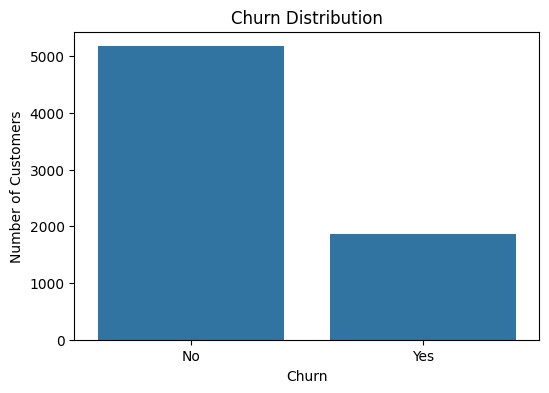

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_raw, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### 2.4 Numerical Feature Analysis

The main numerical features are `tenure`, `MonthlyCharges`, and `TotalCharges`. We compare their distribution for churned and non-churned customers.

In [7]:
df_eda = df_raw.copy()
df_eda["TotalCharges"] = pd.to_numeric(df_eda["TotalCharges"], errors="coerce")

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

# Non-graphical summary grouped by churn
numeric_summary = df_eda.groupby("Churn")[numeric_features].agg(["mean", "median", "min", "max", "std"]).round(2)
numeric_summary

tenure                       MonthlyCharges                        \
        mean median min max    std           mean median    min     max   
Churn                                                                     
No     37.57   38.0   0  72  24.11          61.27  64.43  18.25  118.75   
Yes    17.98   10.0   1  72  19.53          74.44  79.65  18.85  118.35   

             TotalCharges                                    
         std         mean   median    min      max      std  
Churn                                                        
No     31.09      2555.34  1683.60  18.80  8672.45  2329.46  
Yes    24.67      1531.80   703.55  18.85  8684.80  1890.82

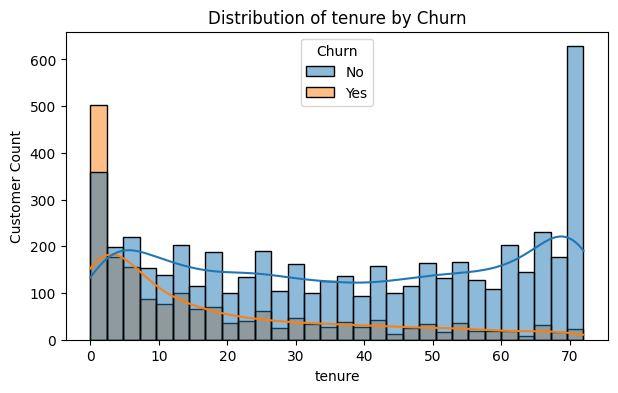

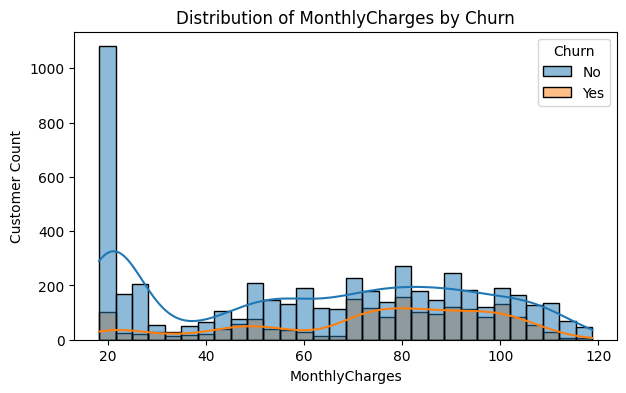

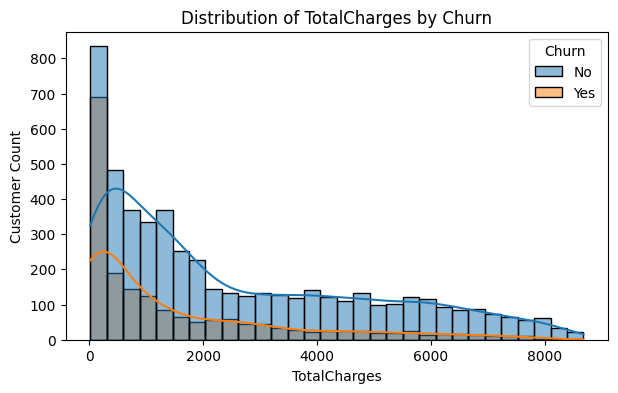

In [8]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df_eda, x=col, hue="Churn", kde=True, bins=30)
    plt.title(f"Distribution of {col} by Churn")
    plt.xlabel(col)
    plt.ylabel("Customer Count")
    plt.show()

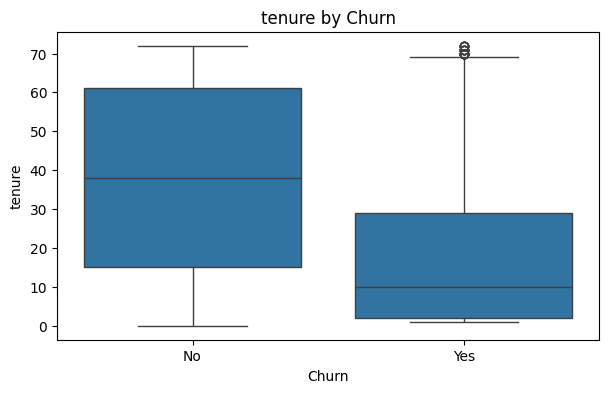

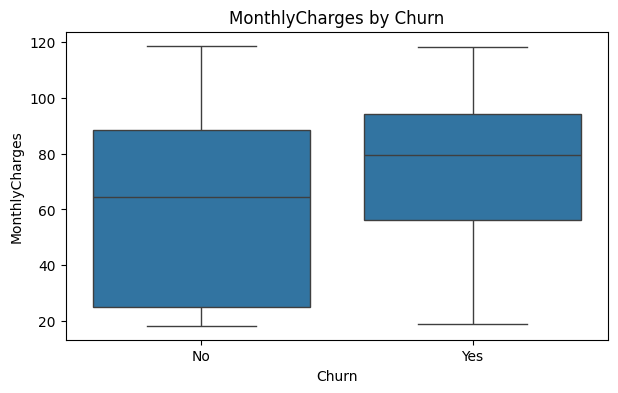

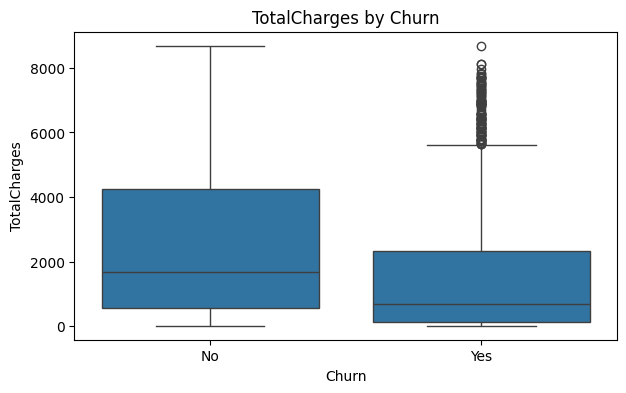

In [9]:
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_eda, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

### 2.5 Categorical Feature Analysis

This section compares churn rate across categorical columns like contract type, internet service, payment method, and support services.

In [10]:
categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"
]

# Churn rate by category for every categorical feature
category_churn_tables = []

for col in categorical_features:
    temp = (
        df_eda.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index(name="churn_rate_percentage")
    )
    temp["feature"] = col
    temp["churn_rate_percentage"] = temp["churn_rate_percentage"].round(2)
    category_churn_tables.append(temp[["feature", col, "churn_rate_percentage"]])

# Show important categorical features first
important_categorical_summary = []
for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "PaperlessBilling"]:
    temp = (
        df_eda.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index(name="churn_rate_percentage")
        .sort_values("churn_rate_percentage", ascending=False)
    )
    temp["churn_rate_percentage"] = temp["churn_rate_percentage"].round(2)
    temp.insert(0, "feature", col)
    important_categorical_summary.append(temp)

pd.concat(important_categorical_summary, ignore_index=True)

,feature,Contract,churn_rate_percentage,InternetService,PaymentMethod,TechSupport,OnlineSecurity,PaperlessBilling
0,Contract,Month-to-month,42.71,NaN,NaN,NaN,NaN,NaN
1,Contract,One year,11.27,NaN,NaN,NaN,NaN,NaN
2,Contract,Two year,2.83,NaN,NaN,NaN,NaN,NaN
3,InternetService,NaN,41.89,Fiber optic,NaN,NaN,NaN,NaN
4,InternetService,NaN,18.96,DSL,NaN,NaN,NaN,NaN
5,InternetService,NaN,7.40,No,NaN,NaN,NaN,NaN
6,PaymentMethod,NaN,45.29,NaN,Electronic check,NaN,NaN,NaN
7,PaymentMethod,NaN,19.11,NaN,Mailed check,NaN,NaN,NaN
8,PaymentMethod,NaN,16.71,NaN,Bank transfer (automatic),NaN,NaN,NaN
9,PaymentMethod,NaN,15.24,NaN,Credit card (automatic),NaN,NaN,NaN


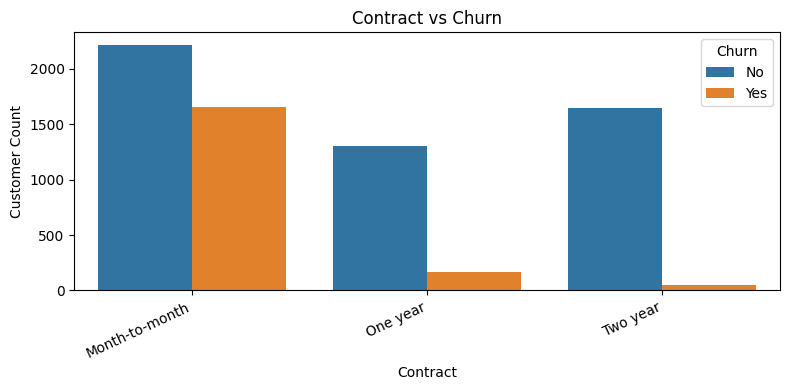

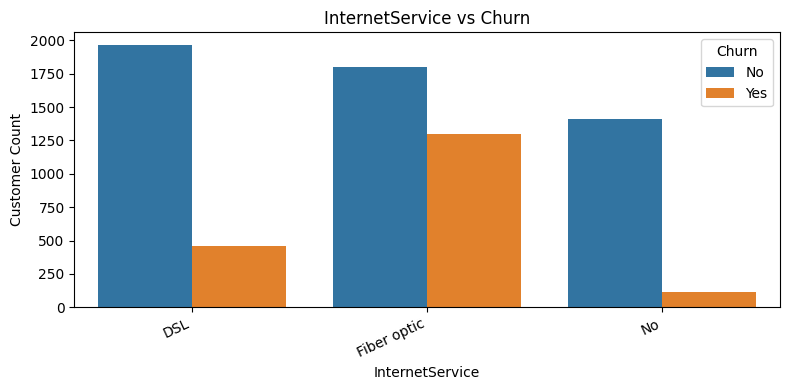

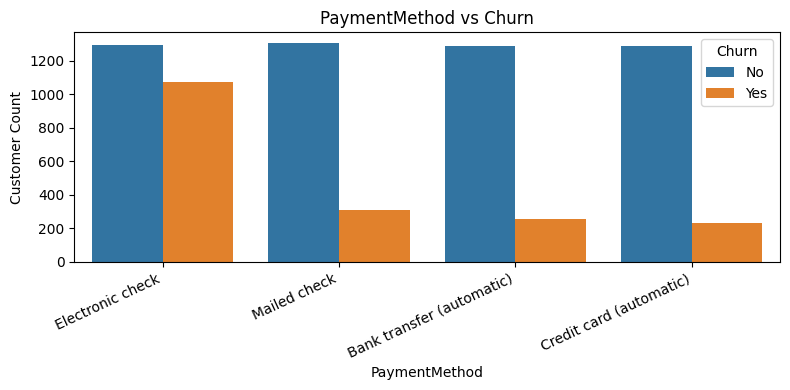

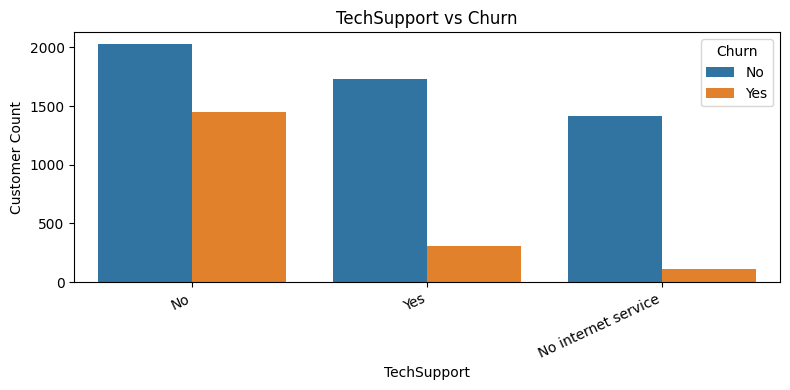

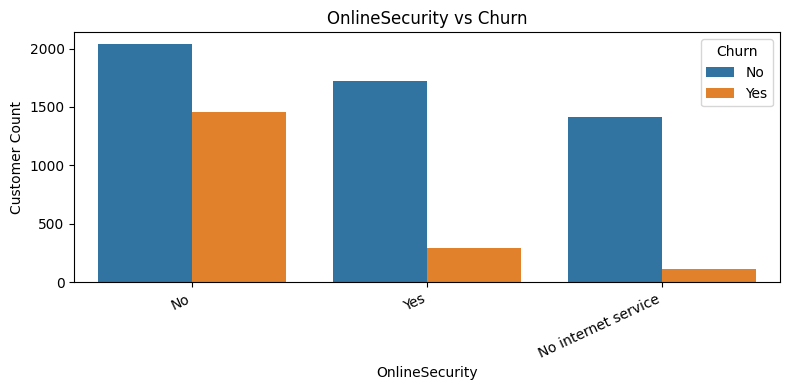

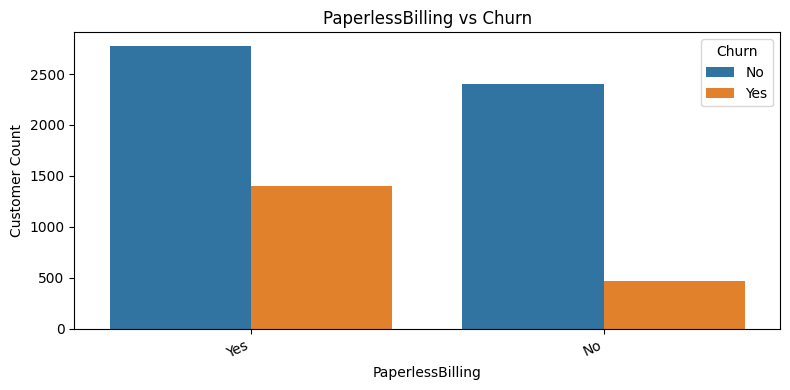

In [11]:
important_categorical_features = [
    "Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity", "PaperlessBilling"
]

for col in important_categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_eda, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Customer Count")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

### 2.6 Churn Rate by Important Categories

Instead of only showing customer counts, this graph shows the churn percentage for each category. This makes it easier to see which groups have higher churn risk.

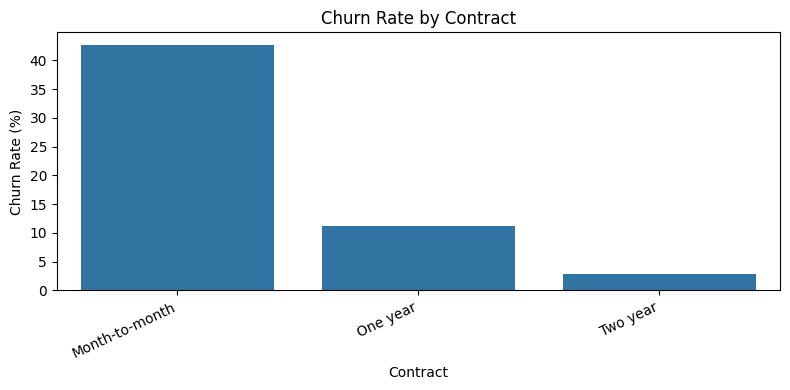

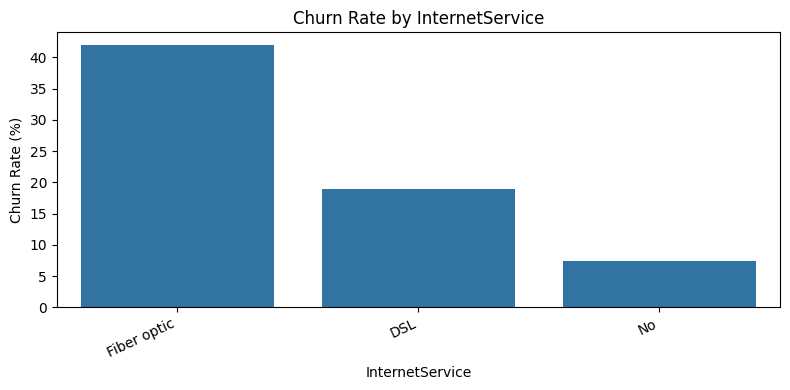

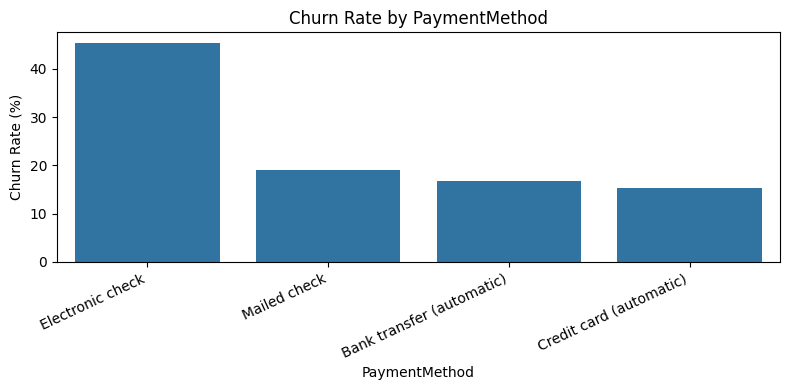

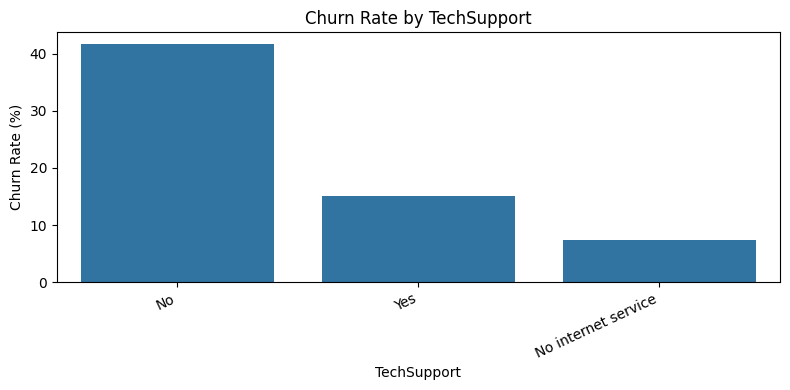

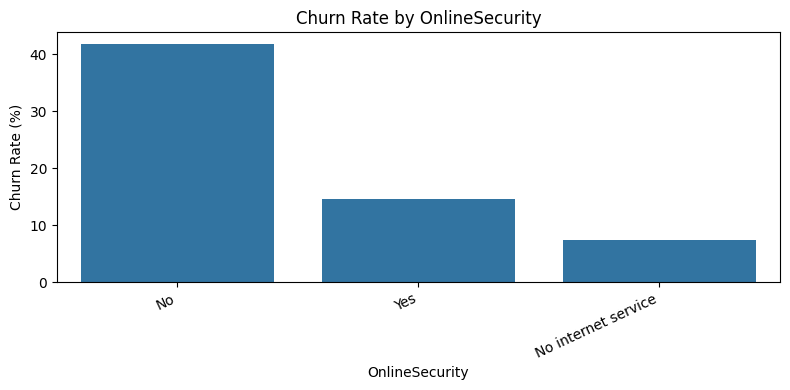

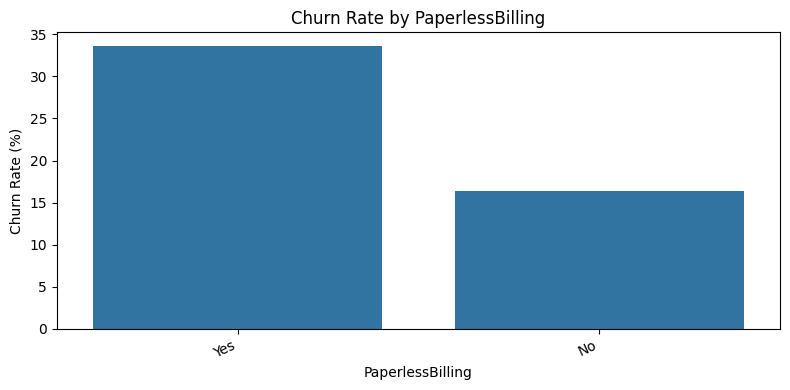

In [12]:
for col in important_categorical_features:
    churn_rate = (
        df_eda.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .reset_index(name="churn_rate_percentage")
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=churn_rate, x=col, y="churn_rate_percentage")
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

### 2.7 Correlation Analysis After Basic Encoding

For correlation, categorical variables need to be converted into numeric values first. This is only for analysis, not the final model training step.

In [13]:
df_corr = df_eda.drop("customerID", axis=1).dropna(subset=["TotalCharges"]).copy()
df_corr["Churn"] = df_corr["Churn"].map({"Yes": 1, "No": 0})
df_corr_encoded = pd.get_dummies(df_corr, drop_first=True)

# Show features with strongest correlation to churn
churn_corr = (
    df_corr_encoded.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

churn_corr.head(15).to_frame("correlation_with_churn")

,correlation_with_churn
tenure,-0.354049
InternetService_Fiber optic,0.307463
Contract_Two year,-0.301552
PaymentMethod_Electronic check,0.301455
InternetService_No,-0.227578
OnlineSecurity_No internet service,-0.227578
DeviceProtection_No internet service,-0.227578
TechSupport_No internet service,-0.227578
StreamingMovies_No internet service,-0.227578
StreamingTV_No internet service,-0.227578


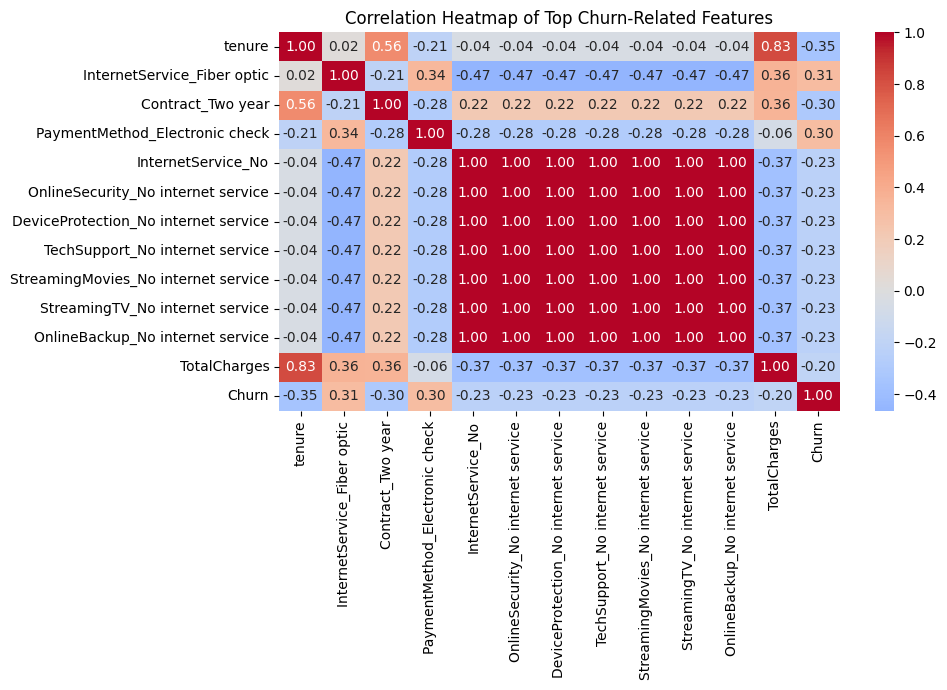

In [14]:
top_corr_features = churn_corr.head(12).index.tolist() + ["Churn"]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df_corr_encoded[top_corr_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Top Churn-Related Features")
plt.tight_layout()
plt.show()

### 2.8 EDA Summary

Based on the EDA, churn is usually higher among customers with shorter tenure, month-to-month contracts, fiber optic internet service, electronic check payment, and missing support services like online security or tech support. This supports the feature choices used later in the model pipeline.

## 3. Preprocess Data for Modeling

In [15]:
df = df_raw.copy()

# Fix hidden missing values & drop ID
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop("customerID", axis=1, inplace=True)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop("Churn", axis=1)
y = df["Churn"]
X = pd.get_dummies(X, drop_first=True)

print(f"Preprocessed feature shape: {X.shape}")
print(f"Churn rate after preprocessing: {y.mean():.2%}")
X.head()

Preprocessed feature shape: (7032, 30)
Churn rate after preprocessing: 26.58%


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## 4. Train/Test Split with Stratification

In [16]:
# Stratified split preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train churn rate: 26.58%
Test churn rate:  26.58%
Train: 5625 | Test: 1407


## 5. Handle Class Imbalance with SMOTE
SMOTE creates synthetic churn examples in the training set only, balancing the classes without leaking test data.

In [17]:
# Apply SMOTE only on training data — never on test data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE — Churn: {y_train.sum()}, No-Churn: {(y_train==0).sum()}")
print(f"After  SMOTE — Churn: {y_train_res.sum()}, No-Churn: {(y_train_res==0).sum()}")

Before SMOTE — Churn: 1495, No-Churn: 4130
After  SMOTE — Churn: 4130, No-Churn: 4130


## 6. Feature Scaling
Logistic Regression is sensitive to feature scale. We fit the scaler strictly on the **original raw X_train** to prevent distribution shifts, then transform both the raw and SMOTE'd datasets.

In [18]:
scaler = StandardScaler()

# ISSUE 1 FIXED: Fit strictly on original training data
scaler.fit(X_train)

# Transform datasets
X_train_res_scaled = scaler.transform(X_train_res)  # Used for Logistic Regression
X_test_scaled      = scaler.transform(X_test)       # Used for Logistic Regression eval
X_train_scaled     = scaler.transform(X_train)      # Used for threshold tuning

## 7. Train Improved Models

In [19]:
# --- Logistic Regression ---
log_model = LogisticRegression(C=0.1, solver="lbfgs", max_iter=1000, random_state=42)
log_model.fit(X_train_res_scaled, y_train_res)  # Uses SMOTE + Scaled data

# --- Random Forest (Production Model) ---
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)  # Uses SMOTE data

# --- Gradient Boosting ---
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42
)
gb_model.fit(X_train_res, y_train_res)  # Uses SMOTE data

# --- XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight, use_label_encoder=False,
    eval_metric="logloss", random_state=42, n_jobs=-1
)

# ISSUE 2 FIXED: XGBoost is trained on raw X_train (no SMOTE).
# Reason: 'scale_pos_weight' natively handles class imbalance by assigning higher weight 
# to the minority class, making synthetic data generation (SMOTE) unnecessary.
xgb_model.fit(X_train, y_train)

print("All models trained.")
print(f"XGBoost scale_pos_weight: {scale_pos_weight:.2f}")

All models trained.
XGBoost scale_pos_weight: 2.76


## 8. Optimise Decision Threshold
Missing an actual churner (false-negative) is costly. We tune the threshold to maximize Recall/F1.

In [20]:
def find_best_threshold(model, X, y_true):
    """Find threshold that maximises F1 score on provided data."""
    probs = model.predict_proba(X)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx] if best_idx < len(thresholds) else 0.5

# ISSUE 3 FIXED: Define the prediction function
def predict_with_threshold(model, X, threshold):
    """Predict classes based on a custom probability threshold."""
    probs = model.predict_proba(X)[:, 1]
    return (probs >= threshold).astype(int)

# Tune thresholds on original validation split (avoids SMOTE distribution distortion)
X_tr_raw, X_val_raw, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
)
X_val_scaled = scaler.transform(X_val_raw)

log_threshold = find_best_threshold(log_model, X_val_scaled, y_val_raw)
rf_threshold  = find_best_threshold(rf_model,  X_val_raw,    y_val_raw)
gb_threshold  = find_best_threshold(gb_model,  X_val_raw,    y_val_raw)
xgb_threshold = find_best_threshold(xgb_model, X_val_raw,    y_val_raw)

print(f"Optimal thresholds — LR: {log_threshold:.2f} | RF: {rf_threshold:.2f} | GB: {gb_threshold:.2f} | XGB: {xgb_threshold:.2f}")

Optimal thresholds — LR: 0.44 | RF: 0.43 | GB: 0.52 | XGB: 0.59


## 9. Evaluate All Models

In [21]:
def evaluate(name, y_true, y_pred, model=None, X=None):
    auc = roc_auc_score(y_true, model.predict_proba(X)[:, 1]) if model is not None and X is not None else None
    auc_str = f" (AUC={auc:.4f})" if auc else ""
    print(f"=== {name}{auc_str} ===")
    print(classification_report(y_true, y_pred, target_names=["No Churn", "Churn"]))

log_preds = predict_with_threshold(log_model, X_test_scaled, log_threshold)
rf_preds  = predict_with_threshold(rf_model,  X_test,        rf_threshold)
gb_preds  = predict_with_threshold(gb_model,  X_test,        gb_threshold)
xgb_preds = predict_with_threshold(xgb_model, X_test,        xgb_threshold)

evaluate("Logistic Regression", y_test, log_preds, log_model, X_test_scaled)
evaluate("Random Forest",       y_test, rf_preds,  rf_model,  X_test)
evaluate("Gradient Boosting",   y_test, gb_preds,  gb_model,  X_test)
evaluate("XGBoost",             y_test, xgb_preds, xgb_model, X_test)

=== Logistic Regression (AUC=0.8160) ===
              precision    recall  f1-score   support

    No Churn       0.88      0.75      0.81      1033
       Churn       0.51      0.70      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407

=== Random Forest (AUC=0.8319) ===
              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1033
       Churn       0.53      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.79      0.75      0.76      1407

=== Gradient Boosting (AUC=0.8299) ===
              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1033
       Churn       0.56      0.61      0.59       374

    accuracy                           0.77      1407
   macro avg 

## 10. Confusion Matrices

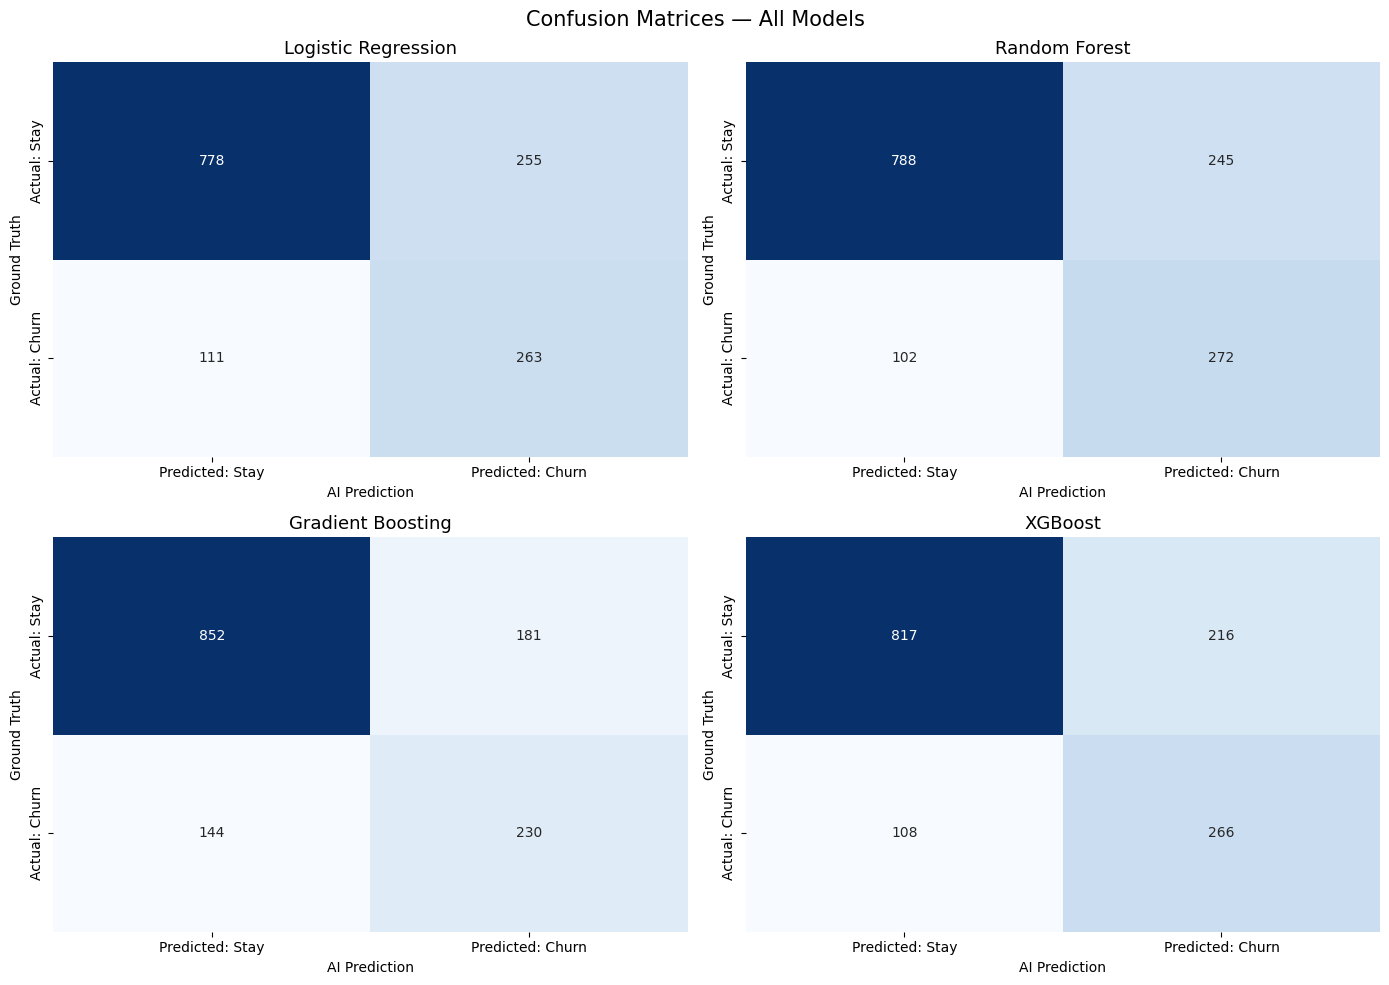

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_info = [
    ("Logistic Regression", log_preds),
    ("Random Forest",        rf_preds),
    ("Gradient Boosting",    gb_preds),
    ("XGBoost",              xgb_preds),
]
for ax, (name, preds) in zip(axes, models_info):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Predicted: Stay", "Predicted: Churn"],
                yticklabels=["Actual: Stay", "Actual: Churn"], ax=ax)
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("AI Prediction")
    ax.set_ylabel("Ground Truth")

plt.suptitle("Confusion Matrices — All Models", fontsize=15)
plt.tight_layout()
plt.show()

In [23]:
import joblib

# 1. Define the XGBoost model as the production model
production_model = xgb_model

# 2. Export the trained model to a .pkl file
joblib.dump(production_model, 'xgboost_churn_model.pkl')

# 3. Export the list of expected feature names
# This ensures the Flask API aligns incoming JSON exactly with the training features
expected_features = list(X_test.columns)
joblib.dump(expected_features, 'model_features.pkl')

print("Model and features successfully exported for Flask!")

Model and features successfully exported for Flask!


## 11. Explainable AI: SHAP (Production Model: Random Forest)
Aligning with the Retentio architecture, the Random Forest model is selected for production to provide actionable insights to CS Agents via SHAP values.

In [24]:
# ISSUES 4 & 5 FIXED: Finalized Random Forest as Production Model.
production_model = rf_model
model_name = "Random Forest"

# Build SHAP explainer
explainer = shap.TreeExplainer(production_model)

# TreeExplainer for Random Forest returns a list of arrays (one per class).
# We extract index 1, which represents the probability of Churn.
shap_values = explainer.shap_values(X_test)[1] 
expected_value = explainer.expected_value[1]

print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {X_test.shape[1]}")

# --- Flask API Output Simulation ---
# Simulating an incoming prediction request for a single customer (e.g., Customer #0 in X_test)
customer_idx = 0
customer_data = X_test.iloc[[customer_idx]]
customer_shap = shap_values[customer_idx]

# Calculate Probability and Risk Level
churn_prob = production_model.predict_proba(customer_data)[0][1]
risk_level = "HIGH" if churn_prob > rf_threshold else "LOW"

# Extract top 2 driving factors (Highest positive SHAP values push towards churn)
feature_names = X_test.columns
shap_dict = [{'feature': f, 'shap_value': s} for f, s in zip(feature_names, customer_shap)]
shap_dict.sort(key=lambda x: x['shap_value'], reverse=True) # Sort descending by impact

top_factors = []
for item in shap_dict[:2]:
    top_factors.append({
        "feature": item['feature'],
        "shap_value": round(item['shap_value'], 4),
        "direction": "increases_risk"
    })

# Final Output Structure for Flask /predict Endpoint
flask_api_response = {
    "churn_probability": round(churn_prob, 4),
    "risk_level": risk_level,
    "top_factors": top_factors
}

print("\n--- Simulated Flask Response ---")
import json
print(json.dumps(flask_api_response, indent=2))

SHAP values shape: (30, 2)
Features: 30

--- Simulated Flask Response ---
{
  "churn_probability": 0.0217,
  "risk_level": "LOW",
  "top_factors": [
    {
      "feature": "tenure",
      "shap_value": 0.0028,
      "direction": "increases_risk"
    },
    {
      "feature": "SeniorCitizen",
      "shap_value": -0.0028,
      "direction": "increases_risk"
    }
  ]
}
